In [1]:
# AMATH 581 HW 1
# Jonathan McCormack 

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl

## Import Data

In [2]:
# Load Training, Validation test, and Unknown test data

# Input features in order: 1.fixed acidity, 2.volatile acidity, 3.citric acid, 4.residual sugar, 5.chlorides
#                          6.free sulfur dioxide, 7.total sulfur dioxide, 8.density, 9.pH, 10.sulphates, 11.alcohol
# Output feature is a quality score between 0 and 10

# Identify current directory and path to data file
print("Current working directory:", Path.cwd())

# load data files
wine_training = np.loadtxt(Path.cwd() / 'wine_training.csv', delimiter=",", unpack=True) # training data
wine_validation = np.loadtxt(Path.cwd() / 'wine_test.csv', delimiter=",", unpack=True) # validation test data
wine_unknown = np.loadtxt(Path.cwd() / 'wine_new_batch.csv', delimiter=",", unpack=True) # unknown test data with unknown output

# Identify dimensions of the data files
print(wine_training.shape); training_size = wine_training.shape[1]
print(wine_validation.shape); validation_size = wine_validation.shape[1]
print(wine_unknown.shape); unknown_size = wine_unknown.shape[1]

X_train = np.transpose(wine_training[0:11]) # the first 11 rows of the original data are the input features
Y_train = np.transpose(wine_training[-1]) # the last row of the original data is the output score

X_validate = np.transpose(wine_validation[0:11])
Y_validate = np.transpose(wine_validation[-1])

X_unknown = np.transpose(wine_unknown[0:11])
# we inherently don't have a output row for the unknown test data


Current working directory: /home/jrmccormack20/Desktop/Code Repositories/AMATH 582/AMATH_582_Project_4
(12, 1115)
(12, 479)
(11, 5)


## Preprocess and Display Data

In [ ]:
# Center and Normalize input feature data

# Normalized data = (data - mean)/ standard deviation
# Mean and Standard deviation is calculated with axis 0 because we average like features

X_train_means = np.mean(X_train, axis=0)
X_train_stds = np.std(X_train, axis=0)
X_train_normal = (X_train - np.matlib.repmat(X_train_means, training_size, 1))/np.matlib.repmat(X_train_stds, training_size, 1)
print(X_train_normal.shape)

X_validate_means = np.mean(X_validate, axis=0)
X_validate_stds = np.std(X_validate, axis=0)
X_validate_normal = (X_validate - np.matlib.repmat(X_validate_means, validation_size, 1))/np.matlib.repmat(X_validate_stds, validation_size, 1)
print(X_validate_normal.shape)

X_unknown_means = np.mean(X_unknown, axis=0)
X_unknown_stds = np.std(X_unknown, axis=0)
X_unknown_normal = (X_unknown - np.matlib.repmat(X_unknown_means, unknown_size, 1))/np.matlib.repmat(X_unknown_stds, unknown_size, 1)
print(X_unknown_normal.shape)

# Note: we will not normalize the output data, but we will use one-hot encoding

(1115, 11)
(479, 11)
(5, 11)


In [4]:
# Implement one hot encoding on output arrays

# We know the output is from 0 to 10, therefore we made a 11x11 Identity matrix 
# and indexed the rows of that matrix using the value of the output array

Y_train_encoded = np.eye(11, dtype=int)[Y_train.astype(int)]
Y_validate_encoded = np.eye(11, dtype=int)[Y_validate.astype(int)]

print(Y_train_encoded.shape, Y_validate_encoded.shape)

(1115, 11) (479, 11)


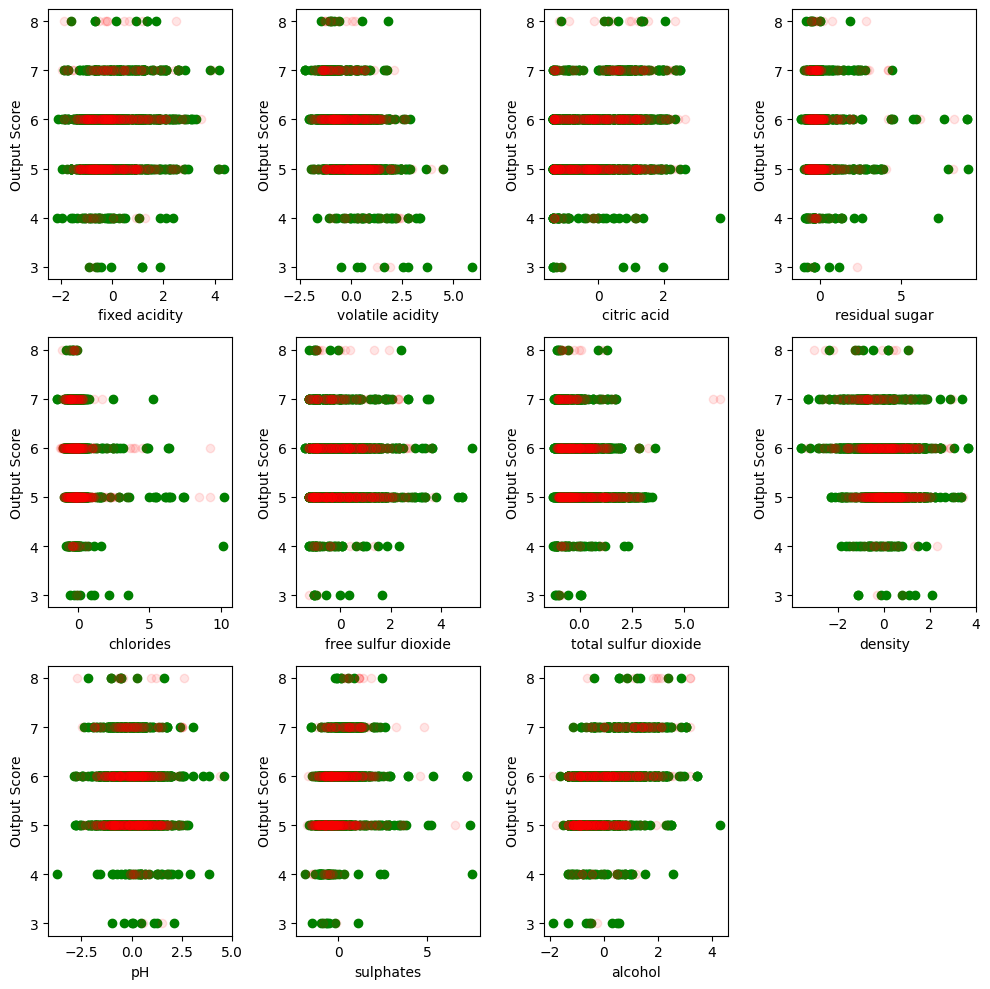

In [5]:
# Plot Scatter plot for training and validation test data sets to show relation between certain factors and certain output levels

features = ['fixed acidity','volatile acidity','citric acid','residual sugar', 
          'chlorides','free sulfur dioxide','total sulfur dioxide','density','pH', 
          'sulphates','alcohol']

fig = plt.figure(figsize=(10,10))
for i in range(11):
    xlabel = features[i]
    plt.subplot(3, 4, i+1)
    plt.scatter(X_train_normal[:,i], Y_train, c='g') # training data
    plt.scatter(X_validate_normal[:,i], Y_validate, c='r', alpha=0.1) # validation test data
    plt.ylabel('Output Score', fontsize=10)
    plt.xlabel(str(xlabel), fontsize=10)
    plt.tight_layout()
plt.show()


## Affine/Linear Regression

In [ ]:
# Necessary Functions for Linear Regression

# Add a ones column to the left of the data matrix
# This ensures Least Squares finds a intercept coefficient
A = np.concatenate((np.ones((X_train_normal.shape[0],1)), X_train_normal), axis = 1)
print(A.shape, Y_train_encoded.shape)

# Def MSE
def mse(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """Compute mean squared error of predictions."""
    return float(np.mean((y_pred - y_true) ** 2))

# Def linear ridge regression

# Def linear k fold cross validation

n_lambdas = 50
lambdas = np.logspace(-1, 3, n_lambdas)




(1115, 12) (1115, 11)


(12, 11)


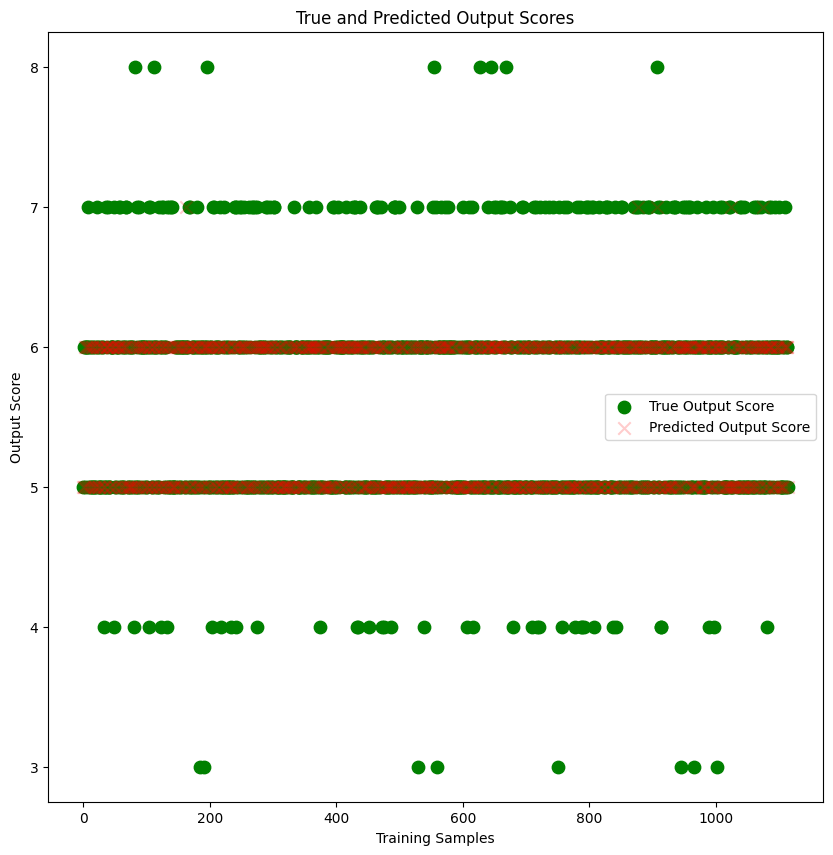

In [13]:
# Linear regression for encoded data without regularization or cross validation

# Least Squares to solve for the theta (coefficient) vector
sol = np.linalg.lstsq(A, Y_train_encoded, rcond=None )
theta = sol[0]
print(theta.shape)

# Predicted Output Score using the model theta vector applied to the training data
Y_train_est = A @ theta
Y_train_est = np.argmax(Y_train_est, axis=1)

# Plot Predicted Output and True Output data
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.scatter(range(X_train_normal.shape[0]), Y_train, s= 80, marker='o', c='g', label='True Output Score')
ax.scatter(range(X_train_normal.shape[0]), Y_train_est, s=80, marker='x', c='r', alpha=0.2, label='Predicted Output Score')
ax.set_xlabel('Training Samples')
ax.set_ylabel('Output Score')
ax.set_title('True and Predicted Output Scores')
ax.legend()
plt.show()


In [ ]:
## define cross validation function for more robust MSE eval??

# Fix a high-complexity model (lots of terms) and vary lambda



## Kernal Methods